In [12]:
## Reading the Data and Importing any libraries

import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.model_selection import train_test_split


In [13]:
## Reading the data

mnist = scipy.io.loadmat('mnist-original.mat')
X = np.transpose(mnist['data'])
y = np.transpose(mnist['label'])
print(X.shape,' ',y.shape)

(70000, 784)   (70000, 1)


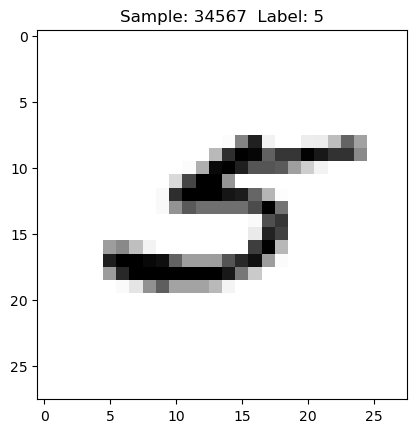

In [14]:
def display_sample(num):
    #Print the one-hot array of this sample's label
    #print(mnist_label[num])
    #Print the label converted back to a number
    label = y[num][0]
    #Reshape the 784 values to a 28x28 image
    image = X[num].reshape([28,28])
    plt.title('Sample: %d  Label: %d' % (num, label))
    plt.imshow(image, cmap=plt.get_cmap('gray_r'))
    plt.show()

display_sample(34567)

## Split the Data into Train and Test

In [15]:
# test_size: what proportion of original data is used for test set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=(1/7.0), random_state=42)

In [16]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 784)
(60000, 1)
(10000, 784)
(10000, 1)


In [17]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.]),
 array([6903, 7877, 6990, 7141, 6824, 6313, 6876, 7293, 6825, 6958],
       dtype=int64))

## Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(X_train, y_train.ravel())

y_pred=rfc.predict(X_test)

In [21]:
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics
# Model Accuracy, how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.971


In [22]:
fi = rfc.feature_importances_

In [23]:
type(fi)

numpy.ndarray

pixel_350    0.010229
pixel_378    0.009923
pixel_406    0.008626
pixel_405    0.008288
pixel_433    0.007938
pixel_462    0.007806
pixel_346    0.007431
pixel_290    0.007396
pixel_434    0.007119
pixel_488    0.007118
pixel_514    0.006890
pixel_375    0.006559
pixel_155    0.006508
pixel_409    0.006468
pixel_347    0.006406
pixel_568    0.006398
pixel_210    0.006366
pixel_211    0.006230
pixel_657    0.006117
pixel_461    0.006071
dtype: float64


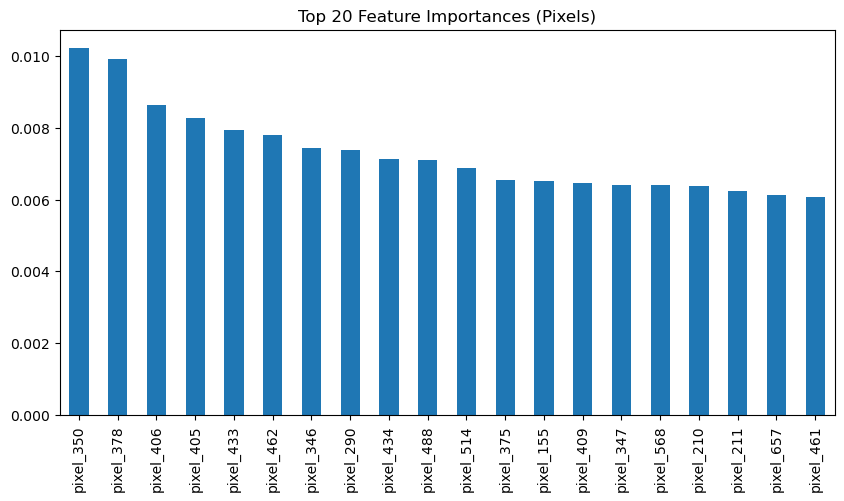

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the trained Random Forest model
feature_imp = pd.Series(rfc.feature_importances_, 
                        index=[f'pixel_{i}' for i in range(X_train.shape[1])]) \
                        .sort_values(ascending=False)

# Print the Top 20 most important pixels
print(feature_imp.head(20))

# Plot the Top 20 most important pixels as a bar chart
plt.figure(figsize=(10,5))
feature_imp[:20].plot(kind='bar')
plt.title("Top 20 Feature Importances (Pixels)")
plt.show()

In [ ]:
np.median(fi)

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score

# Step 5: Evaluate the model
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")



Confusion Matrix:
[[ 968    0    2    0    0    0    4    0    7    1]
 [   0 1109    4    3    3    0    3    0    1    1]
 [   8    2  965    3    2    2    2    8    7    0]
 [   1    0   10  970    0    7    0   11    8    1]
 [   2    0    0    0  904    0    4    3    2   13]
 [   0    0    1   11    0  884   10    0    9    4]
 [   5    0    1    0    1    1 1021    0    3    0]
 [   3    1   11    2    4    0    0 1041    2    5]
 [   1    4    3    4    6   10    0    0  949    9]
 [   6    3    0   16   10    2    1    8    8  899]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98       982
         1.0       0.99      0.99      0.99      1124
         2.0       0.97      0.97      0.97       999
         3.0       0.96      0.96      0.96      1008
         4.0       0.97      0.97      0.97       928
         5.0       0.98      0.96      0.97       919
         6.0       0.98      0.99      0.98     

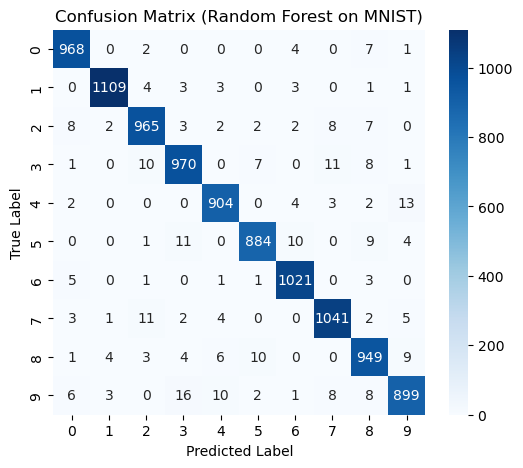

In [28]:
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=np.arange(10),
            yticklabels=np.arange(10))

plt.title("Confusion Matrix (Random Forest on MNIST)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --- 1) Fit a baseline RF ONLY on the training set to get clean importances (no leakage) ---
rf_base = RandomForestClassifier(
    n_estimators=200,      # a bit larger for stabler importances
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train, y_train.ravel())

# --- 2) Sort features by importance (descending) ---
importances = rf_base.feature_importances_
order = np.argsort(importances)[::-1]   # indices of features from most to least important

# --- 3) Helper to select the top-k features (same columns for train/test) ---
def select_top_k(X, order, k):
    """Return X restricted to the k most important columns given by 'order'."""
    return X[:, order[:k]]

# --- 4) Build the K grid to test ---
# Feel free to tweak this grid; add more points around the "elbow/saturation" you observe.
K_GRID = [25, 50, 75, 100, 125, 150, 200, 250, 300, 400, 500, 784]

accs = []

# --- 5) Train/evaluate a new RF for each k and store accuracy ---
for k in K_GRID:
    Xtr_k = select_top_k(X_train, order, k)
    Xte_k = select_top_k(X_test,  order, k)

    rf = RandomForestClassifier(
        n_estimators=200,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
    rf.fit(Xtr_k, y_train.ravel())
    y_pred_k = rf.predict(Xte_k)
    acc_k = accuracy_score(y_test, y_pred_k)
    accs.append(acc_k)

# --- 6) Optionally compute the "cumulative-importance" k at 95% and 99% ---
sorted_imps = importances[order]
cum_imp = np.cumsum(sorted_imps) / sorted_imps.sum()

def k_for_threshold(th):
    """Smallest k such that cumulative importance >= th (e.g., 0.95)."""
    return int(np.searchsorted(cum_imp, th) + 1)

k_95 = k_for_threshold(0.95)
k_99 = k_for_threshold(0.99)

# --- 7) Find the best k on the grid (max accuracy) ---
best_idx = int(np.argmax(accs))
best_k = K_GRID[best_idx]
best_acc = accs[best_idx]

print(f"Best k on grid: {best_k} features — Accuracy: {best_acc:.4f}")
print(f"k for 95% cumulative importance: {k_95}")
print(f"k for 99% cumulative importance: {k_99}")

# --- 8) Plot Accuracy vs Number of Features and annotate useful reference points ---
plt.figure(figsize=(8,5))
plt.plot(K_GRID, accs, marker='o', linewidth=2)
plt.title("Accuracy vs Number of Features (Random Forest on MNIST)")
plt.xlabel("Number of features (top-k by importance)")
plt.ylabel("Accuracy")
plt.grid(True, alpha=0.3)

# Mark the best point
plt.scatter([best_k], [best_acc], s=120, marker='*', label=f"Best on grid: k={best_k}", zorder=3)

# Add vertical guide lines for 95% and 99% cumulative importance (only if <= 784)
if k_95 <= 784:
    plt.axvline(k_95, linestyle="--", alpha=0.6, label=f"95% cum. imp. ≈ k={k_95}")
if k_99 <= 784:
    plt.axvline(k_99, linestyle=":",  alpha=0.6, label=f"99% cum. imp. ≈ k={k_99}")

plt.legend()
plt.show()
